Saved: iceberg_motion_plots.png


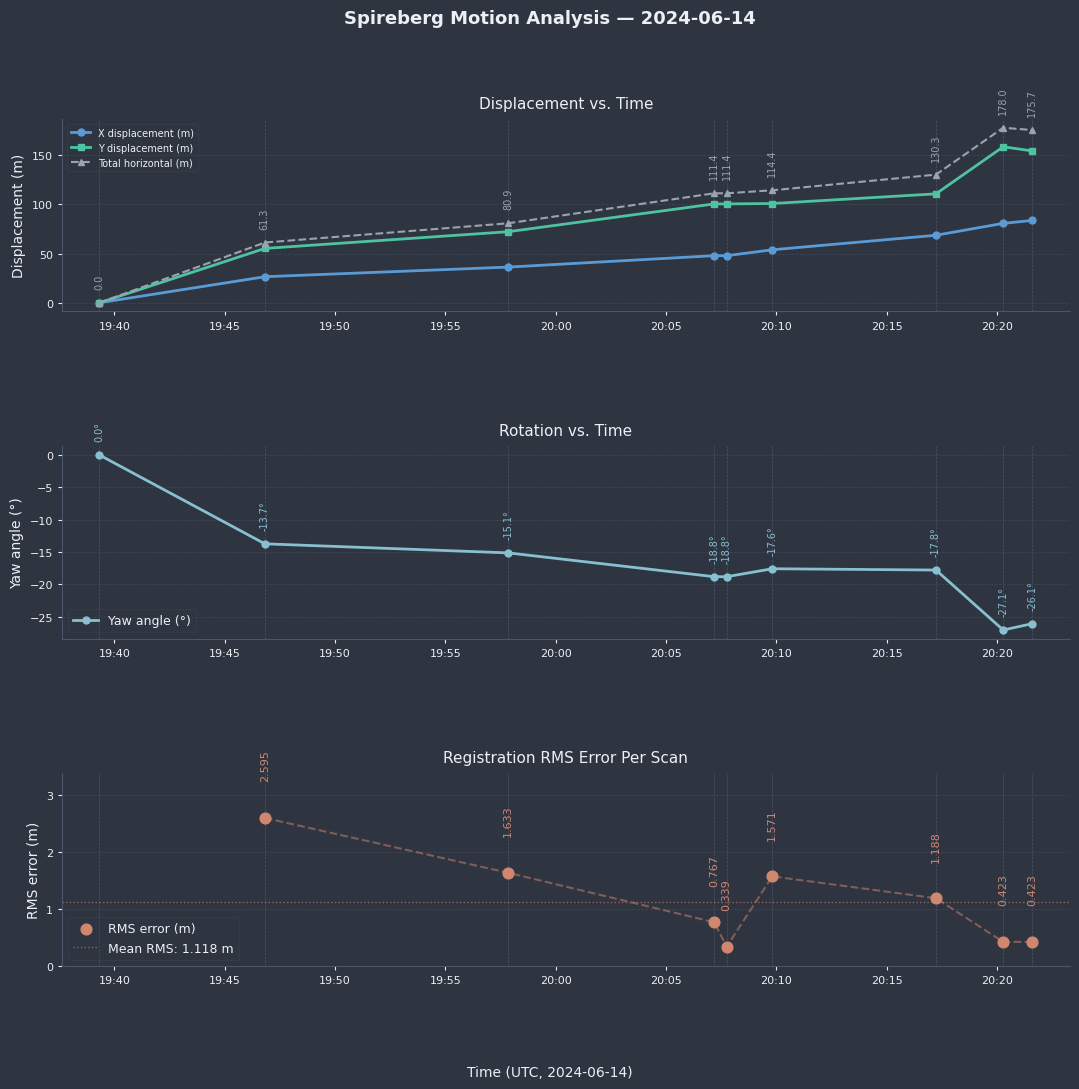

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Data

REF = np.array([-132.41, 56.8226, -13.5595, 1.0])

scans = [
    {
        "label": "Swath 0 Pass 1",
        "midtime": "2024-06-14 19:39:19",
        "rms": None,
        "T": np.eye(4, dtype=float),
    },
    {
        "label": "Swath 0 Pass 3",
        "midtime": "2024-06-14 19:46:49",
        "rms": 2.5954,
        "T": np.array([
            [ 0.971371,  0.237567, 0, -56.142044],
            [-0.237567,  0.971371, 0, -77.208176],
            [0, 0, 1, 0], [0, 0, 0, 1],
        ], dtype=float),
    },
    {
        "label": "Swath 1 Pass 1",
        "midtime": "2024-06-14 19:57:51",
        "rms": 1.63322,
        "T": np.array([
            [ 0.965258,  0.261299, 0, -73.347969],
            [-0.261299,  0.965258, 0, -92.914001],
            [0, 0, 1, 0], [0, 0, 0, 1],
        ], dtype=float),
    },
    {
        "label": "Swath 2 Pass 1",
        "midtime": "2024-06-14 20:07:11",
        "rms": 0.766883,
        "T": np.array([
            [ 0.946475,  0.322779, 0, -103.207397],
            [-0.322779,  0.946475, 0, -119.397728],
            [0, 0, 1, 0], [0, 0, 0, 1],
        ], dtype=float),
    },
    {
        "label": "Swath 2 Pass 2",
        "midtime": "2024-06-14 20:07:45",
        "rms": 0.339418,
        "T": np.array([
            [ 0.946475,  0.322779, 0, -103.207397],
            [-0.322779,  0.946475, 0, -119.397728],
            [0, 0, 1, 0], [0, 0, 0, 1],
        ], dtype=float),
    },
    {
        "label": "Swath 2 Pass 3",
        "midtime": "2024-06-14 20:09:49",
        "rms": 1.57113,
        "T": np.array([
            [ 0.953180,  0.302402, 0, -105.259834],
            [-0.302402,  0.953181, 0, -117.300385],
            [0, 0, 1, 0], [0, 0, 0, 1],
        ], dtype=float),
    },
    {
        "label": "Swath 3 Pass 1",
        "midtime": "2024-06-14 20:17:14",
        "rms": 1.18801,
        "T": np.array([
            [ 0.952125,  0.305710,  0, -122.947014],
            [-0.305711,  0.952125,  0, -122.262192],
            [0, 0, 1, 0.000004], [0, 0, 0, 1],
        ], dtype=float),
    },
    {
        "label": "Swath 3 Pass 2",
        "midtime": "2024-06-14 20:20:17",
        "rms": 0.423144,
        "T": np.array([
            [ 0.890380,  0.455220, 0, -184.515457],
            [-0.455220,  0.890380, 0, -158.540604],
            [0, 0, 1, 0], [0, 0, 0, 1],
        ], dtype=float),
    },
    {
        "label": "Swath 4 Pass 1",
        "midtime": "2024-06-14 20:21:36",
        "rms": 0.423144,
        "T": np.array([
            [ 0.898033,  0.439928, 0, -181.639328],
            [-0.439928,  0.898033, 0, -154.327957],
            [0, 0, 1, 0], [0, 0, 0, 1],
        ], dtype=float),
    },
]

# Compute Actual Translation

fmt = "%Y-%m-%d %H:%M:%S"
for s in scans:
    T_inv      = np.linalg.inv(s["T"])
    p_moved    = T_inv @ REF
    s["dx"]    = p_moved[0] - REF[0]
    s["dy"]    = p_moved[1] - REF[1]
    s["total"] = np.linalg.norm([s["dx"], s["dy"]])
    s["yaw"]   = np.degrees(np.arctan2(s["T"][1, 0], s["T"][0, 0]))
    s["dt"]    = datetime.strptime(s["midtime"], fmt)

times  = [s["dt"]    for s in scans]
dx     = [s["dx"]    for s in scans]
dy     = [s["dy"]    for s in scans]
total  = [s["total"] for s in scans]
yaw    = [s["yaw"]   for s in scans]
labels = [s["label"] for s in scans]

rms_times = [s["dt"]  for s in scans if s["rms"] is not None]
rms_vals  = [s["rms"] for s in scans if s["rms"] is not None]

# Style — dark theme matched to slide palette

BG         = "#2e3440"   # dark charcoal background
FG         = "#eceff4"   # near-white text
GRID       = "#3d4455"   # subtle gridlines
VLINE      = "#4c566a"   # scan marker verticals
SPINE      = "#4c566a"   # axis spines

BLUE       = "#5b9bd5"   # X displacement
TEAL       = "#4fc3a1"   # Y displacement
WHITE_GRAY = "#9aa3b0"   # total magnitude
LIGHT_BLUE = "#88c0d0"   # yaw
ORANGE     = "#d08770"   # RMS

time_fmt = mdates.DateFormatter("%H:%M")
margin   = timedelta(seconds=(times[-1] - times[0]).total_seconds() * 0.04)
xlim     = (times[0] - margin, times[-1] + margin)

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(SPINE)
    ax.tick_params(colors=FG, length=3)
    ax.grid(axis="y", color=GRID, lw=0.6, linestyle="--")
    ax.xaxis.set_major_formatter(time_fmt)
    ax.set_xlim(*xlim)
    plt.setp(ax.get_xticklabels(), fontsize=8, color=FG)
    plt.setp(ax.get_yticklabels(), fontsize=8, color=FG)
    for t in times:
        ax.axvline(t, color=VLINE, lw=0.5, linestyle="--", zorder=0)

title_kw = dict(fontsize=11, fontweight="500", color=FG, pad=8)
label_kw = dict(fontsize=10, color=FG)

# Figure

fig = plt.figure(figsize=(13, 11))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.7)

# Displacement
ax1 = fig.add_subplot(gs[0])
style_ax(ax1)

ax1.plot(times, dx,    color=BLUE,       lw=2,   marker="o", ms=5, label="X displacement (m)")
ax1.plot(times, dy,    color=TEAL,       lw=2,   marker="s", ms=5, label="Y displacement (m)")
ax1.plot(times, total, color=WHITE_GRAY, lw=1.5, marker="^", ms=4,
         linestyle="--", label="Total horizontal (m)")

for t, vx, vy, vt in zip(times, dx, dy, total):
    ax1.annotate(f"{vt:.1f}", xy=(t, vt), xytext=(0, 10), textcoords="offset points",
                 ha="center", va="bottom", fontsize=7, color=WHITE_GRAY, rotation=90)

ax1.set_title("Displacement vs. Time", **title_kw)
ax1.set_ylabel("Displacement (m)", **label_kw)
ax1.legend(fontsize=7, framealpha=0.2, loc="upper left",
           facecolor=BG, edgecolor=SPINE, labelcolor=FG)

# Yaw
ax2 = fig.add_subplot(gs[1])
style_ax(ax2)

ax2.plot(times, yaw, color=LIGHT_BLUE, lw=2, marker="o", ms=5, label="Yaw angle (°)")

for t, yw in zip(times, yaw):
    ax2.annotate(f"{yw:.1f}°", xy=(t, yw), xytext=(0, 10), textcoords="offset points",
                 ha="center", va="bottom", fontsize=7, color=LIGHT_BLUE, rotation=90)

ax2.set_title("Rotation vs. Time", **title_kw)
ax2.set_ylabel("Yaw angle (°)", **label_kw)
ax2.legend(fontsize=9, framealpha=0.2, loc="lower left",
           facecolor=BG, edgecolor=SPINE, labelcolor=FG)
# RMS
ax3 = fig.add_subplot(gs[2])
style_ax(ax3)

ax3.scatter(rms_times, rms_vals, color=ORANGE, s=60, zorder=3, label="RMS error (m)")
ax3.plot(rms_times, rms_vals, color=ORANGE, lw=1.5, linestyle="--", alpha=0.5)

for t, val in zip(rms_times, rms_vals):
    ax3.text(t, val + 1.2, f"{val:.3f}",
             ha="center", va="top", fontsize=8, rotation=90, color=ORANGE)

mean_rms = np.mean(rms_vals)
ax3.axhline(mean_rms, color=ORANGE, lw=1, linestyle=":",
            alpha=0.6, label=f"Mean RMS: {mean_rms:.3f} m")
ax3.set_title("Registration RMS Error Per Scan", **title_kw)
ax3.set_ylabel("RMS error (m)", **label_kw)
ax3.set_ylim(0, max(rms_vals) * 1.3)
ax3.legend(fontsize=9, framealpha=0.2, loc="lower left",
           facecolor=BG, edgecolor=SPINE, labelcolor=FG)

fig.text(0.5, 0.01, "Time (UTC, 2024-06-14)", ha="center", fontsize=10, color=FG)

plt.suptitle("Spireberg Motion Analysis — 2024-06-14",
             fontsize=13, fontweight="1000", color=FG, y=0.98)

plt.savefig("iceberg_motion_plots.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved: iceberg_motion_plots.png")
plt.show()